In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.integrate import dblquad, quad
from scipy.integrate import solve_ivp, simpson


In [2]:
mpl.rc('figure', figsize=(12, 6))
mpl.rc('text', usetex = False)
mpl.rc('font', family = 'serif')
mpl.rc('font', size = '14')
mpl.rc('xtick', labelsize=14) 
mpl.rc('ytick', labelsize=14)
mpl.rcParams['mathtext.fontset'] = 'stix'

In [3]:
# Calculo del periodo de oscilación del inflatón en el potencial lphi4
# Función para calcular el período de oscilación del inflatón
def oscilation(E):
    def integrand(phi):
        V = 0.5 * phi**2
        return 1.0 / np.sqrt(2 * (E - V))
    phimax = np.sqrt(2*E)
    integral, _ = quad(integrand, 0, phimax, args=())
    Tosc = 4*integral
    return Tosc
# ----------------------------------------------------------------------

"""Dinámica"""

# Dinamica sin expansión del universo para el modelo lphi4
def pert(t, y, k, g):
        phi, phi_dot, chi_k, chi_dot_k = y
        phi_ddot = - phi
        chi_ddot_k = - (k**2 + g**2 * phi**2) * chi_k
        return [phi_dot, phi_ddot, chi_dot_k, chi_ddot_k]

# Dinamica con expansión del universo para el modelo lphi4
def pert_exp(t, y, k, g):
    phi, phi_dot, chi_k, chi_dot_k, a, a_dot = y

    # Evolución de a(t)
    a_ddot = - a/3 * (phi_dot**2 - phi**2/2)
    H = a_dot/a
    
    # Ecuación para φ
    phi_ddot = -3 * H * phi_dot - phi **3
    
    # Ecuaciones para χ_k
    chi_ddot_k = - 3 * H * chi_dot_k - (k ** 2 / a**2 + g ** 2 * phi**2) * chi_k 
    
    return [phi_dot, phi_ddot, chi_dot_k, chi_ddot_k, a_dot, a_ddot]

# Número de partículas producidas en el modo k
def number(k, g, phi, chik, chidot, a):
    omega_k = np.sqrt(k**2/a**2 + g**2 * phi**2)
    nk = omega_k / 2 * ( (np.abs(chidot)/omega_k)**2 + np.abs(chik)**2 )
    return nk, omega_k

#-------------------------------------------------------------------------------------------------------------------------------------
"""Condiciones iniciales"""
def CI(k, g):
    # Background
    phi0 = 1e6
    phi_dot0 = 0 #phi0

    # Perturbaciones
    Omega_chi = np.sqrt(k**2 + g**2 * phi0**2)
    chi_k0 = 0.0001#1/(np.sqrt(2 * Omega_chi))
    chi_dot_k0 = 0#np.sqrt(Omega_chi/2) 

    y0 = [phi0, phi_dot0, chi_k0, chi_dot_k0]
    return y0

def CI_exp(k, g):
    # Background
    phi0 = 1e6
    phi_dot0 = 0 #phi0**2/np.sqrt(2)
    areh = 1
    a_dot0 = np.sqrt( (phi_dot0**2/2 + phi0**2/2) / 3 ) * areh

    # Perturbaciones
    Omega_chi = np.sqrt(k**2 + g**2 * phi0**2)
    chi_k0 = 0 #1/(np.sqrt(2 * Omega_chi))
    chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_chi))) #np.sqrt(Omega_chi/2)

    y0 = [phi0, phi_dot0, chi_k0, chi_dot_k0, areh, a_dot0]
    return y0

In [4]:
"""Parámetros"""

# Narrow Resonance
qn = 1e-6
kn = 0.6883952069645496

# Broad Resonance
qb = 4e-5
kb = 4.079534503452449

# Condiciones iniciales
y0 = CI(kn, qn)
phi0, phi_dot0 = y0[0], y0[1]

# Tiempos
Tosc = oscilation(0.5 * phi_dot0**2 + 0.5 * phi0**2)
t_span = (0, 10 * Tosc)

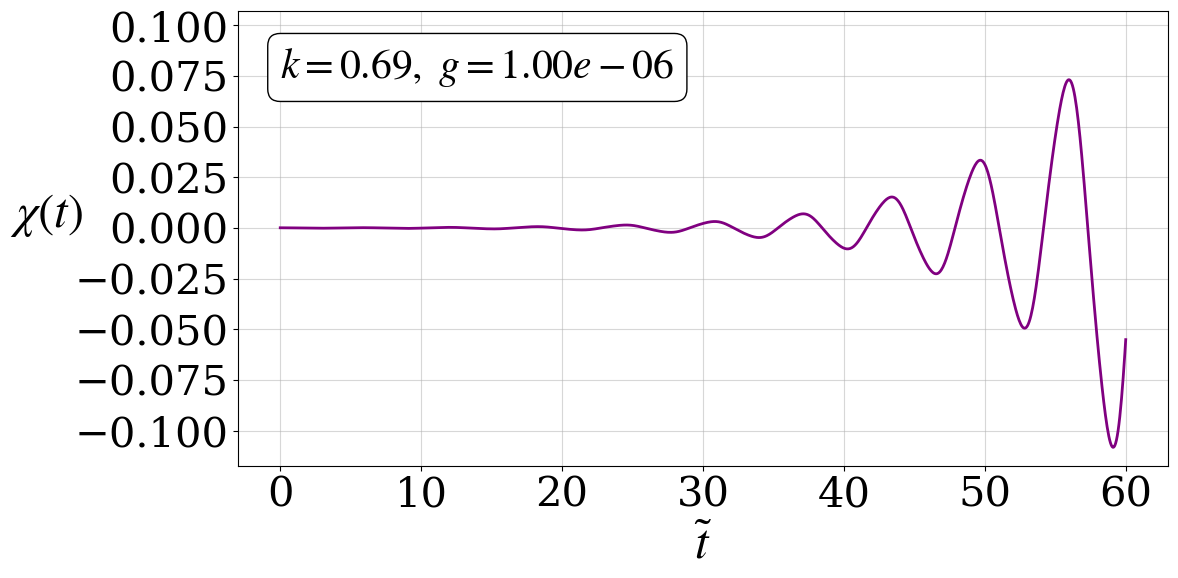

In [5]:
sol_narrow = solve_ivp(pert, t_span, y0, t_eval=np.linspace(t_span[0], 60, 1000), method='RK45', rtol=1e-6, args=(kn, qn))

plt.figure(figsize=(12, 6))
plt.plot(sol_narrow.t, sol_narrow.y[2], lw = 2, color = "purple")
ymin, ymax = plt.gca().get_ylim()
plt.ylim(ymin, ymax*1.3)
plt.xlabel(r'$\tilde{t}$', fontsize = 35)
plt.ylabel(r'$\chi(t)$', labelpad=20, rotation='horizontal', fontsize = 35)
plt.text(x=sol_narrow.t[0], y=ymax*0.9, s=rf'$k = {kn:.2f}, ~ g = {qn:.2e}$', fontsize=30, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.tight_layout()
plt.grid(alpha=0.5)
#plt.show()
plt.savefig("Narrow_Resonance_m2phi2.pdf", format = "pdf")

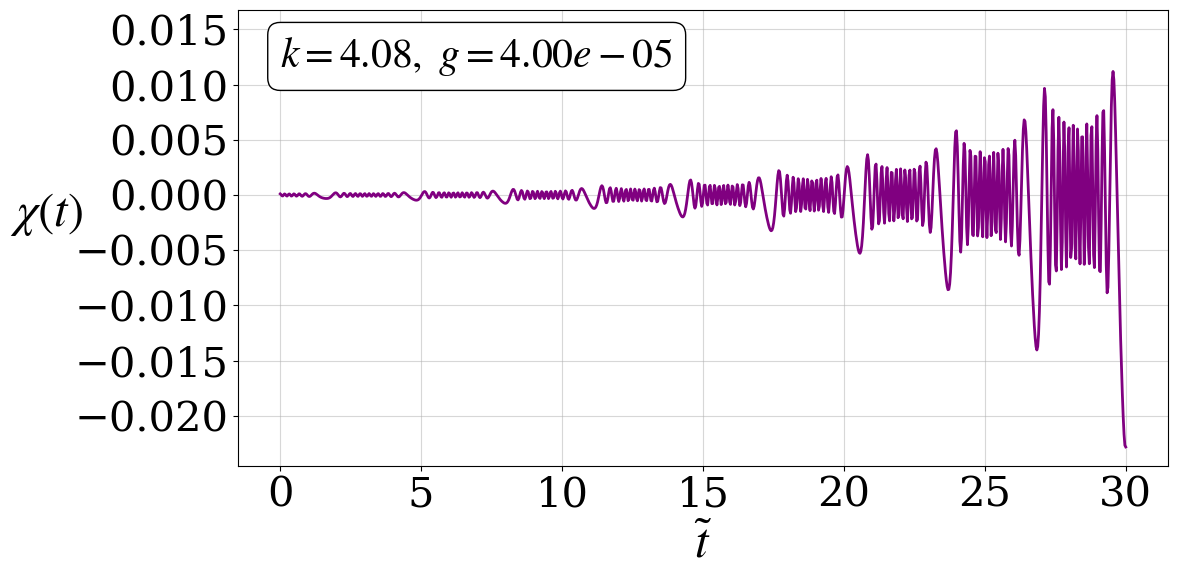

In [6]:
sol_broad = solve_ivp(pert, t_span, y0, t_eval=np.linspace(t_span[0], 30, 1000), method='RK45', rtol=1e-6, args=(kb, qb))

plt.figure(figsize=(12, 6))
plt.plot(sol_broad.t, sol_broad.y[2], lw = 2, color = "purple")
plt.grid(alpha=0.5)
ymin, ymax = plt.gca().get_ylim()
plt.ylim(ymin, ymax*1.3)
plt.xlabel(r'$\tilde{t}$', fontsize = 35)
plt.ylabel(r'$\chi(t)$', labelpad=20, rotation='horizontal', fontsize = 35)
plt.text(x=sol_broad.t[0], y=ymax*0.9, s=rf'$k = {kb:.2f}, ~ g = {qb:.2e}$', fontsize=30, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.tight_layout()
#plt.show()
plt.savefig("Broad_Resonance_m2phi2.pdf", format = "pdf")

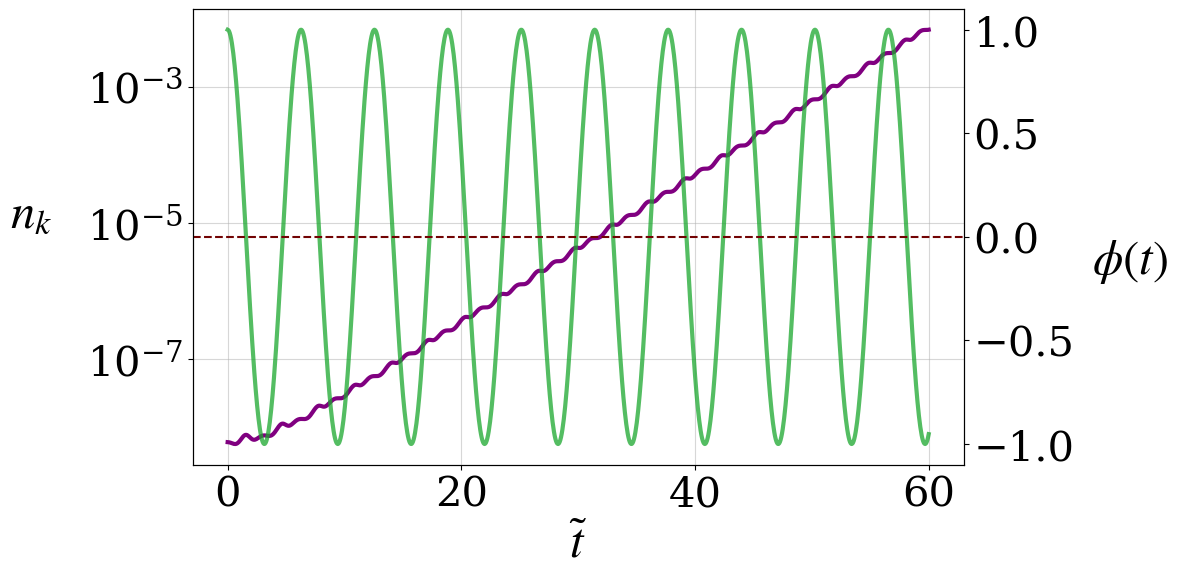

In [7]:
nk, omegak = number(kn, qn, sol_narrow.y[0], sol_narrow.y[2], sol_narrow.y[3], 1)
t = sol_narrow.t

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.semilogy(t, nk, lw = 3, color = "purple", zorder = 20)
ax1.set_xlabel(r'$\tilde{t}$', fontsize = 35)
ax1.set_ylabel(r'$n_k$', fontsize = 35, rotation='horizontal', labelpad=40)
ax1.tick_params(axis='x', labelsize=30)
ax1.tick_params(axis='y', labelsize=30)
ax1.grid(alpha=0.5)

ax2 = ax1.twinx()
ax2.plot(t, sol_narrow.y[0]/1e6, lw = 3, color = "#1BA72E", alpha = 0.75)
ax2.axhline(y = 0, ls = "--", color = "#720303")
ax2.set_ylabel(r'$\phi(t)$', fontsize = 35, rotation='horizontal', labelpad=40)
ax2.tick_params(axis='y', labelsize=30)

fig.tight_layout()
#plt.show()
fig.savefig("nk_Narrow_Resonance_m2phi2.pdf", format = "pdf")

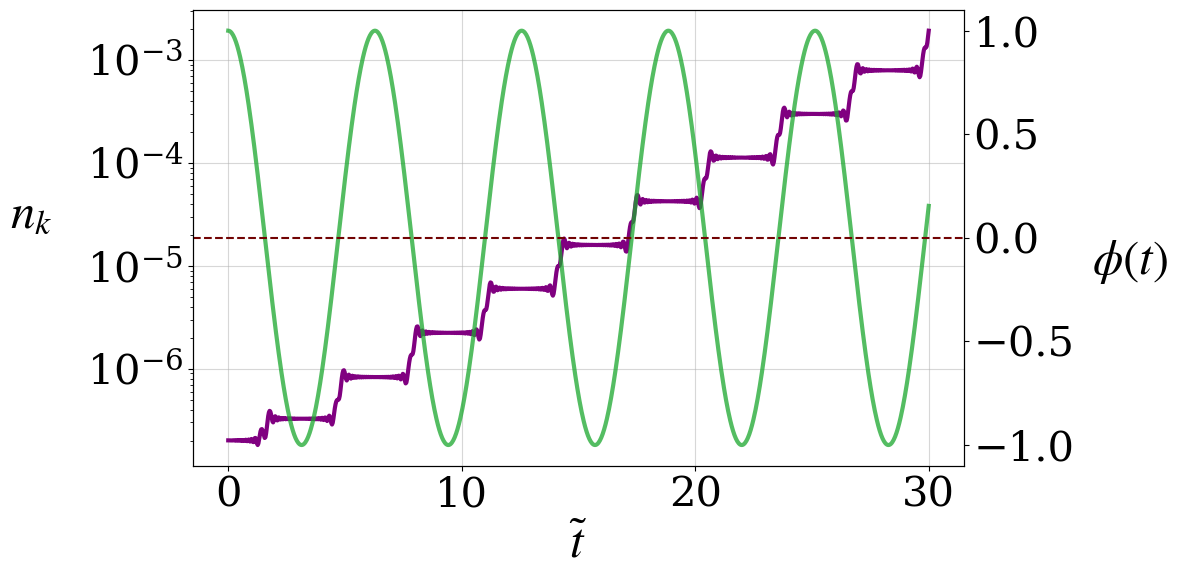

In [8]:
nk, omegak = number(kb, qb, sol_broad.y[0], sol_broad.y[2], sol_broad.y[3], 1)
t = sol_broad.t

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.semilogy(t, nk, lw = 3, color = "purple", zorder = 20)
ax1.set_xlabel(r'$\tilde{t}$', fontsize = 35)
ax1.set_ylabel(r'$n_k$', fontsize = 35, rotation='horizontal', labelpad=40)
ax1.tick_params(axis='x', labelsize=30)
ax1.tick_params(axis='y', labelsize=30)
ax1.grid(alpha=0.5)

ax2 = ax1.twinx()
ax2.plot(t, sol_broad.y[0]/1e6, lw = 3, color = "#1BA72E", alpha = 0.75)
ax2.axhline(y = 0, ls = "--", color = "#720303")
ax2.set_ylabel(r'$\phi(t)$', fontsize = 35, rotation='horizontal', labelpad=40)
ax2.tick_params(axis='y', labelsize=30)

fig.tight_layout()
#plt.show()
fig.savefig("nk_Broad_Resonance_m2phi2.pdf", format = "pdf")